# 04 Combined Model and Final Results

Combine indicator votes with the feed-forward neural-network classifier, then write the final `results/results_table.csv`.

In [1]:
# Project configuration and reproducibility
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    SEED,
    START_DATE,
    END_DATE,
    TRAIN_END_DATE,
    TICKERS,
    CACHE_DIR,
    RESULTS_DIR,
    CHARTS_DIR,
    TRANSACTION_COST,
    set_global_seed,
    ensure_directories,
)

set_global_seed(SEED)
ensure_directories()
print(f"Configured {len(TICKERS)} US/UK indices from {START_DATE} to {END_DATE} with seed={SEED}.")


Configured 7 US/UK indices from 2013-01-01 to 2023-01-01 with seed=42.


## Build execution note

These notebooks were rebuilt from scratch with clean metadata and empty outputs. Live data execution was not completed during repository build because the sandbox could not resolve Yahoo Finance hosts. After installing `requirements.txt` in a normal networked environment, run the notebooks in order from `01_data.ipynb` to `04_combined_model.ipynb`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.backtest import apply_backtest, save_results_table, summarize_backtest
from src.signals import indicator_features, indicator_signals

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
def load_cached_data() -> dict[str, pd.DataFrame]:
    import re

    frames = {}
    for name, symbol in TICKERS.items():
        cache_path = CACHE_DIR / (re.sub(r"[^A-Za-z0-9]+", "_", symbol).strip("_") + ".csv")
        if cache_path.exists():
            frames[name] = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    if not frames:
        raise FileNotFoundError("No cached data found. Run notebooks/01_data.ipynb first.")
    return frames

price_data = load_cached_data()
print(f"Loaded {len(price_data)} cached US/UK indices.")


Loaded 7 cached US/UK indices.


In [4]:
def train_feed_forward_signal(frame: pd.DataFrame) -> pd.Series:
    features = indicator_features(frame)
    model_frame = frame.join(features).dropna()
    feature_cols = list(features.columns)
    split_date = pd.Timestamp(TRAIN_END_DATE)
    train = model_frame.loc[model_frame.index <= split_date]
    test = model_frame.loc[model_frame.index > split_date]

    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                MLPClassifier(
                    hidden_layer_sizes=(32, 16),
                    alpha=0.001,
                    max_iter=500,
                    early_stopping=True,
                    random_state=SEED,
                ),
            ),
        ]
    )
    model.fit(train[feature_cols], train["direction"].astype(int))
    pred = model.predict(test[feature_cols])
    return pd.Series(pred, index=test.index, name="Feed-forward neural network")


def indicator_vote_signal(frame: pd.DataFrame) -> pd.Series:
    raw = pd.concat(indicator_signals(frame).values(), axis=1)
    vote = raw.ffill().fillna(0).mean(axis=1)
    return pd.Series((vote >= 0.5).astype(int), index=frame.index, name="Indicator vote")


In [5]:
rows = []
combined_backtests = {}

for index_name, frame in price_data.items():
    indicator_signal = indicator_vote_signal(frame)
    ml_signal = train_feed_forward_signal(frame)
    combined = pd.concat(
        [indicator_signal.reindex(ml_signal.index), ml_signal],
        axis=1,
    ).dropna()
    combined_signal = (combined.mean(axis=1) >= 0.5).astype(int)
    combined_signal.name = "Combined signal"

    result = apply_backtest(frame.loc[combined_signal.index], combined_signal, cost=TRANSACTION_COST)
    rows.append(summarize_backtest(index_name, "Combined signal", result))
    combined_backtests[index_name] = result

combined_results = save_results_table(rows, RESULTS_DIR / "combined_results.csv")
combined_results.sort_values("Sharpe", ascending=False)


,index,strategy,gross_return,net_return,ann_vol,Sharpe,max_drawdown,n_trades,vs_buy_and_hold
0,S&P 500,Combined signal,0.181540,0.180359,0.255702,0.216448,-0.339250,1,-0.011081
1,Dow Jones Industrial Average,Combined signal,0.150751,0.149601,0.252937,0.183971,-0.370862,1,-0.014471
2,NASDAQ Composite,Combined signal,0.152427,0.151276,0.296296,0.158689,-0.363953,1,-0.016512
6,Cboe Volatility Index,Combined signal,0.719326,0.717608,1.307992,0.138036,-0.818479,1,0.161730
3,Russell 2000,Combined signal,0.063449,0.062386,0.323235,0.062490,-0.418749,1,0.003781
4,FTSE 100,Combined signal,-0.012046,-0.013033,0.208789,-0.020972,-0.349295,1,-0.009096
5,Cboe UK 100,Combined signal,-0.012455,-0.013442,0.206102,-0.021887,-0.352675,1,-0.002770


In [6]:
parts = []
for filename in ["indicator_results.csv", "ml_results.csv", "combined_results.csv"]:
    path = RESULTS_DIR / filename
    if path.exists():
        parts.append(pd.read_csv(path))

if parts:
    final_results = pd.concat(parts, ignore_index=True)
    final_results = final_results.sort_values(["index", "Sharpe"], ascending=[True, False])
    final_results.to_csv(RESULTS_DIR / "results_table.csv", index=False)
else:
    final_results = save_results_table([], RESULTS_DIR / "results_table.csv")

final_results.head(20)


,index,strategy,gross_return,net_return,ann_vol,Sharpe,max_drawdown,n_trades,vs_buy_and_hold
26,Cboe UK 100,RSI,0.222466,0.221244,0.156082,0.127598,-0.371714,1,-0.022568
28,Cboe UK 100,Bollinger Bands,0.198082,0.196885,0.157458,0.113733,-0.371714,1,-0.046927
29,Cboe UK 100,Momentum,0.189632,0.188443,0.158230,0.108722,-0.371714,1,-0.055369
25,Cboe UK 100,MACD,0.174007,0.172833,0.158021,0.100528,-0.371714,1,-0.070979
27,Cboe UK 100,SMA crossover,0.156831,0.155674,0.157730,0.091402,-0.371714,1,-0.088138
50,Cboe UK 100,Logistic Regression,-0.007311,-0.008303,0.206075,-0.013486,-0.352675,1,0.002369
51,Cboe UK 100,Random Forest,-0.012455,-0.013442,0.206102,-0.021887,-0.352675,1,-0.002770
52,Cboe UK 100,Feed-forward neural network,-0.012455,-0.013442,0.206102,-0.021887,-0.352675,1,-0.002770
61,Cboe UK 100,Combined signal,-0.012455,-0.013442,0.206102,-0.021887,-0.352675,1,-0.002770
53,Cboe Volatility Index,Logistic Regression,0.719326,0.717608,1.307992,0.138036,-0.818479,1,0.161730


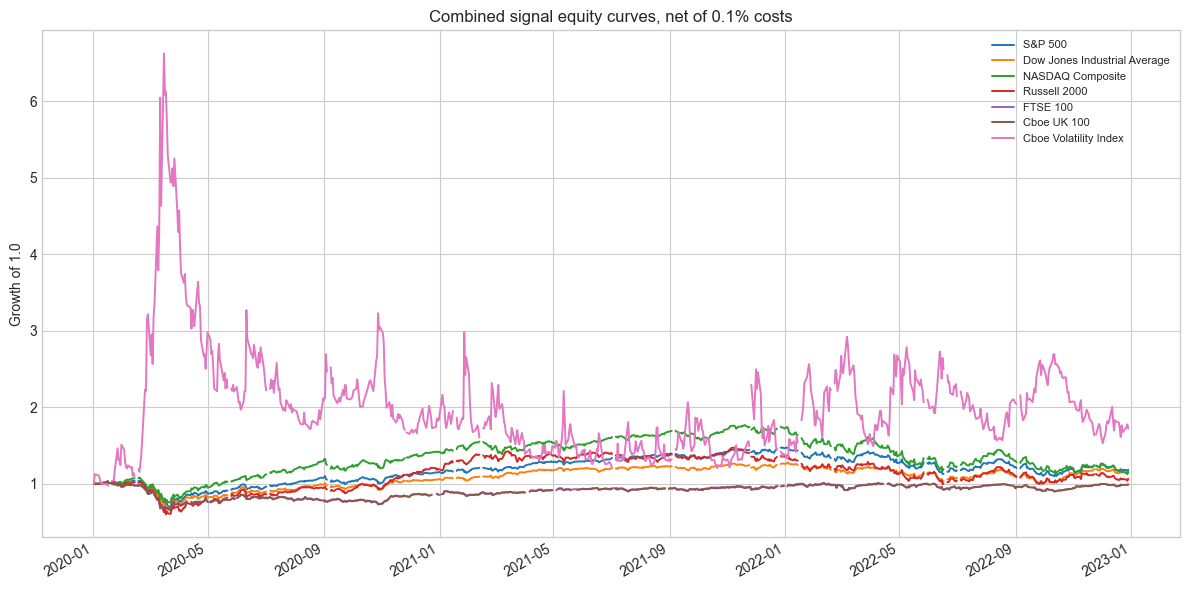

In [7]:
if combined_backtests:
    curves = []
    for index_name, result in combined_backtests.items():
        curve = np.exp(result["net_strategy_return"].cumsum())
        curve.name = index_name
        curves.append(curve)

    fig, ax = plt.subplots(figsize=(12, 6))
    pd.concat(curves, axis=1).plot(ax=ax, linewidth=1.4)
    ax.set_title("Combined signal equity curves, net of 0.1% costs")
    ax.set_ylabel("Growth of 1.0")
    ax.set_xlabel("")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(CHARTS_DIR / "combined_equity_curves.png", dpi=160)
    plt.show()
